
IMAGE ENHANCEMENT AND SEGMENTATION DEMONSTRATION
Topics: Convolution, Spatial Enhancement, Filters, Segmentation

✅ All operations use mathematical formulas from scratch
✅ Supports any image format (JPG, PNG, BMP, TIFF, GIF, WEBP, PGM)
✅ Auto-resizes to 720p max


📤 Please upload an image:
Click 'Choose File' button below and select your image
Or press 'Cancel' to use test image
--------------------------------------------------


Saving 7.jpg to 7 (1).jpg

✓ Loaded: 7 (1).jpg (236x356)

1. CONVOLUTION AND EXPANDED EQUATION

1. CONVOLUTION AND EXPANDED EQUATION

[1] Convolution Theory
    ✓ Convolution theory displayed: (f * h)(x,y) = Σ f(x-i,y-j) * h(i,j)

[2] Expanded Convolution Equation
    ✓ Expanded convolution equation for 3x3 kernel

[3] Kernel Visualization
    ✓ 5 different kernels visualized

[4] Convolution with Different Kernels
    ✓ Applied: Box (3x3)
    ✓ Applied: Box (5x5)
    ✓ Applied: Sharpen
    ✓ Applied: Laplacian
    ✓ Applied: Edge Detect
    ✓ Applied: Smooth


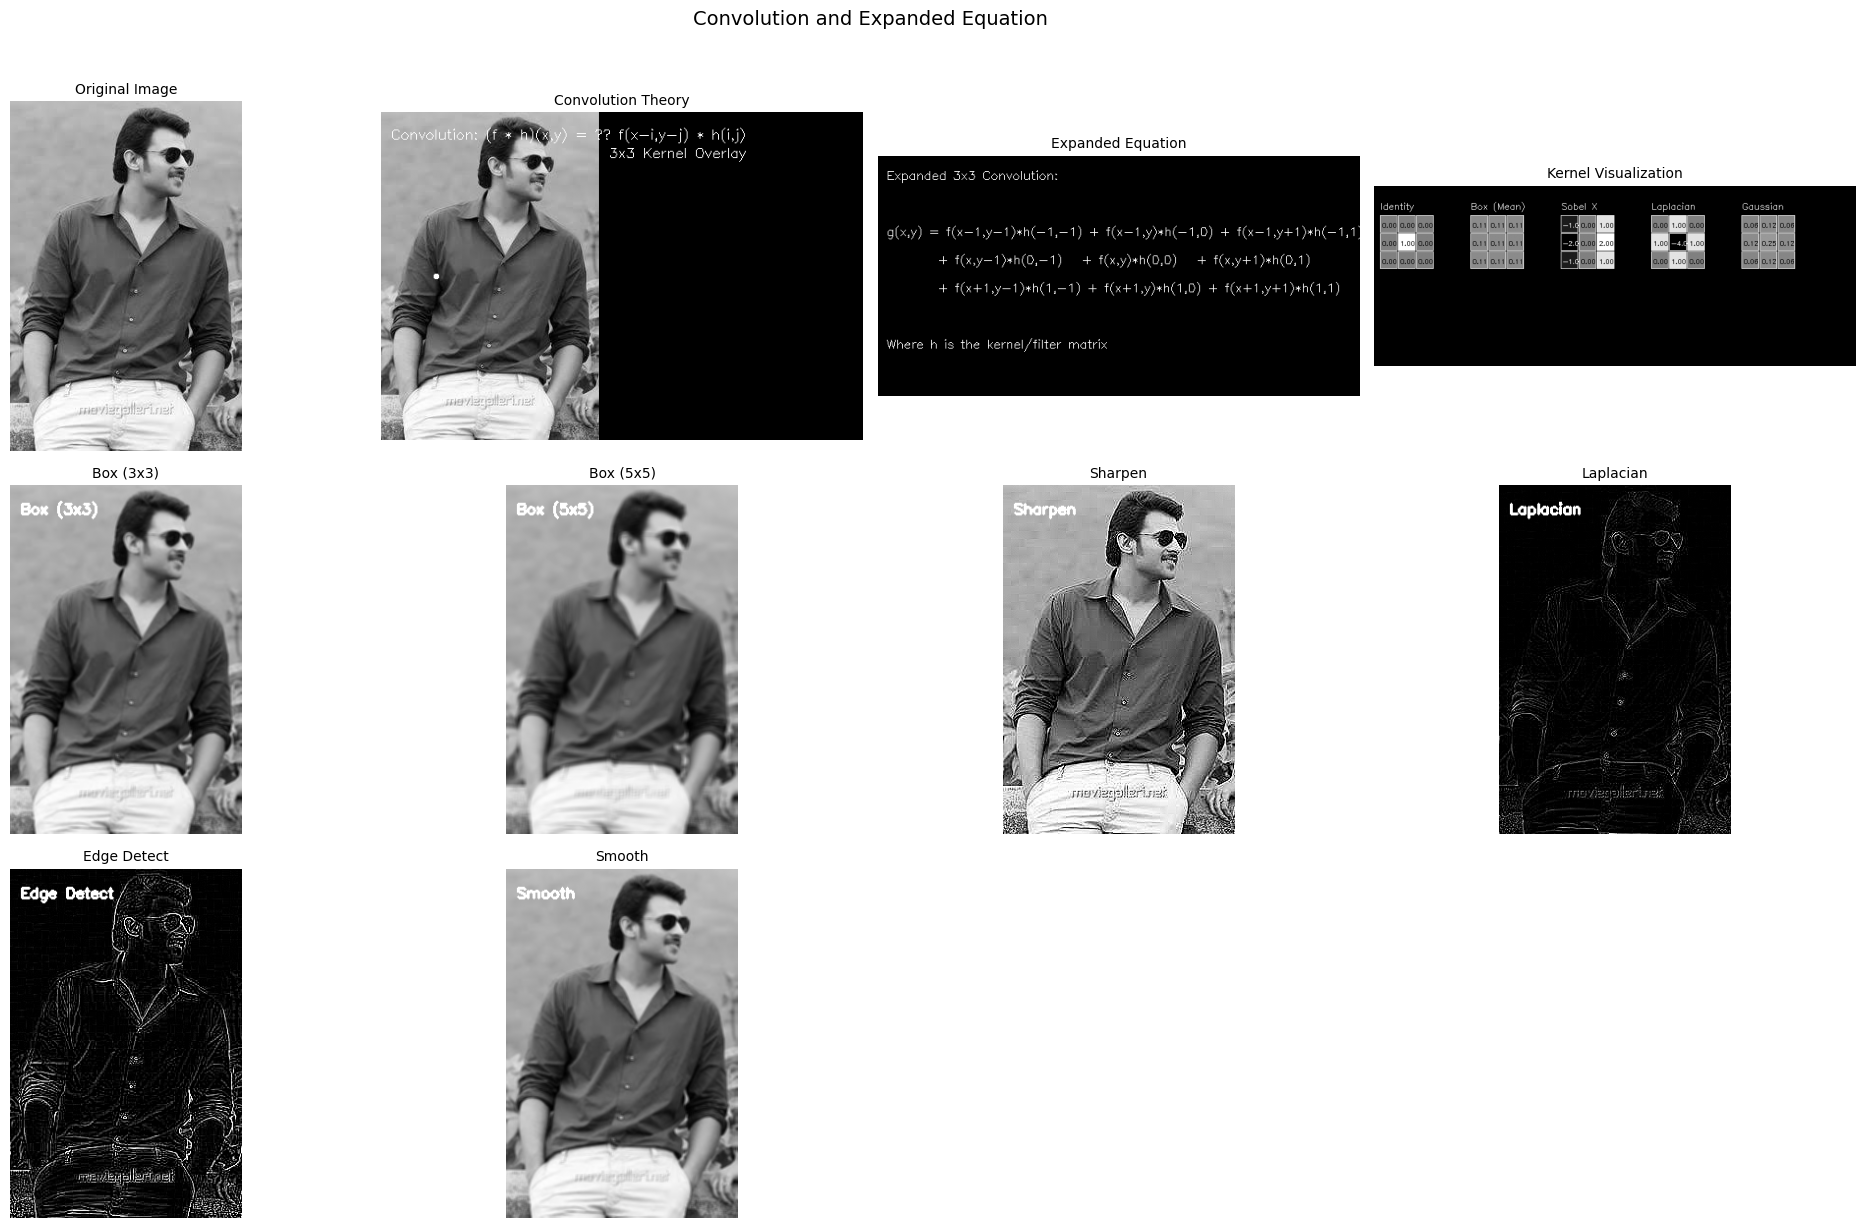


2. IMAGE ENHANCEMENT IN SPATIAL DOMAIN

2. IMAGE ENHANCEMENT IN SPATIAL DOMAIN

[1] Point Processing (Intensity Transformations)
    ✓ Negative: s = L-1-r
    ✓ Log transform: s = c*log(1+r)
    ✓ Power-law: s = c*r^γ, γ=0.5
    ✓ Contrast stretching: s = (r-min)/(max-min)*255

[2] Histogram Processing
    ✓ Histogram equalization: s = T(r) = (L-1) * Σ p_r(j)
    ✓ CLAHE applied

[3] Neighborhood Processing (Spatial Filtering)
    ✓ Mean filter applied
    ✓ Median filter applied
    ✓ Gaussian filter applied

[4] Edge Enhancement
    ✓ Unsharp masking: g = f + α(f - f_smooth)
    ✓ Laplacian sharpening applied

[5] Enhancement Comparison
    ✓ Comparison of enhancement techniques


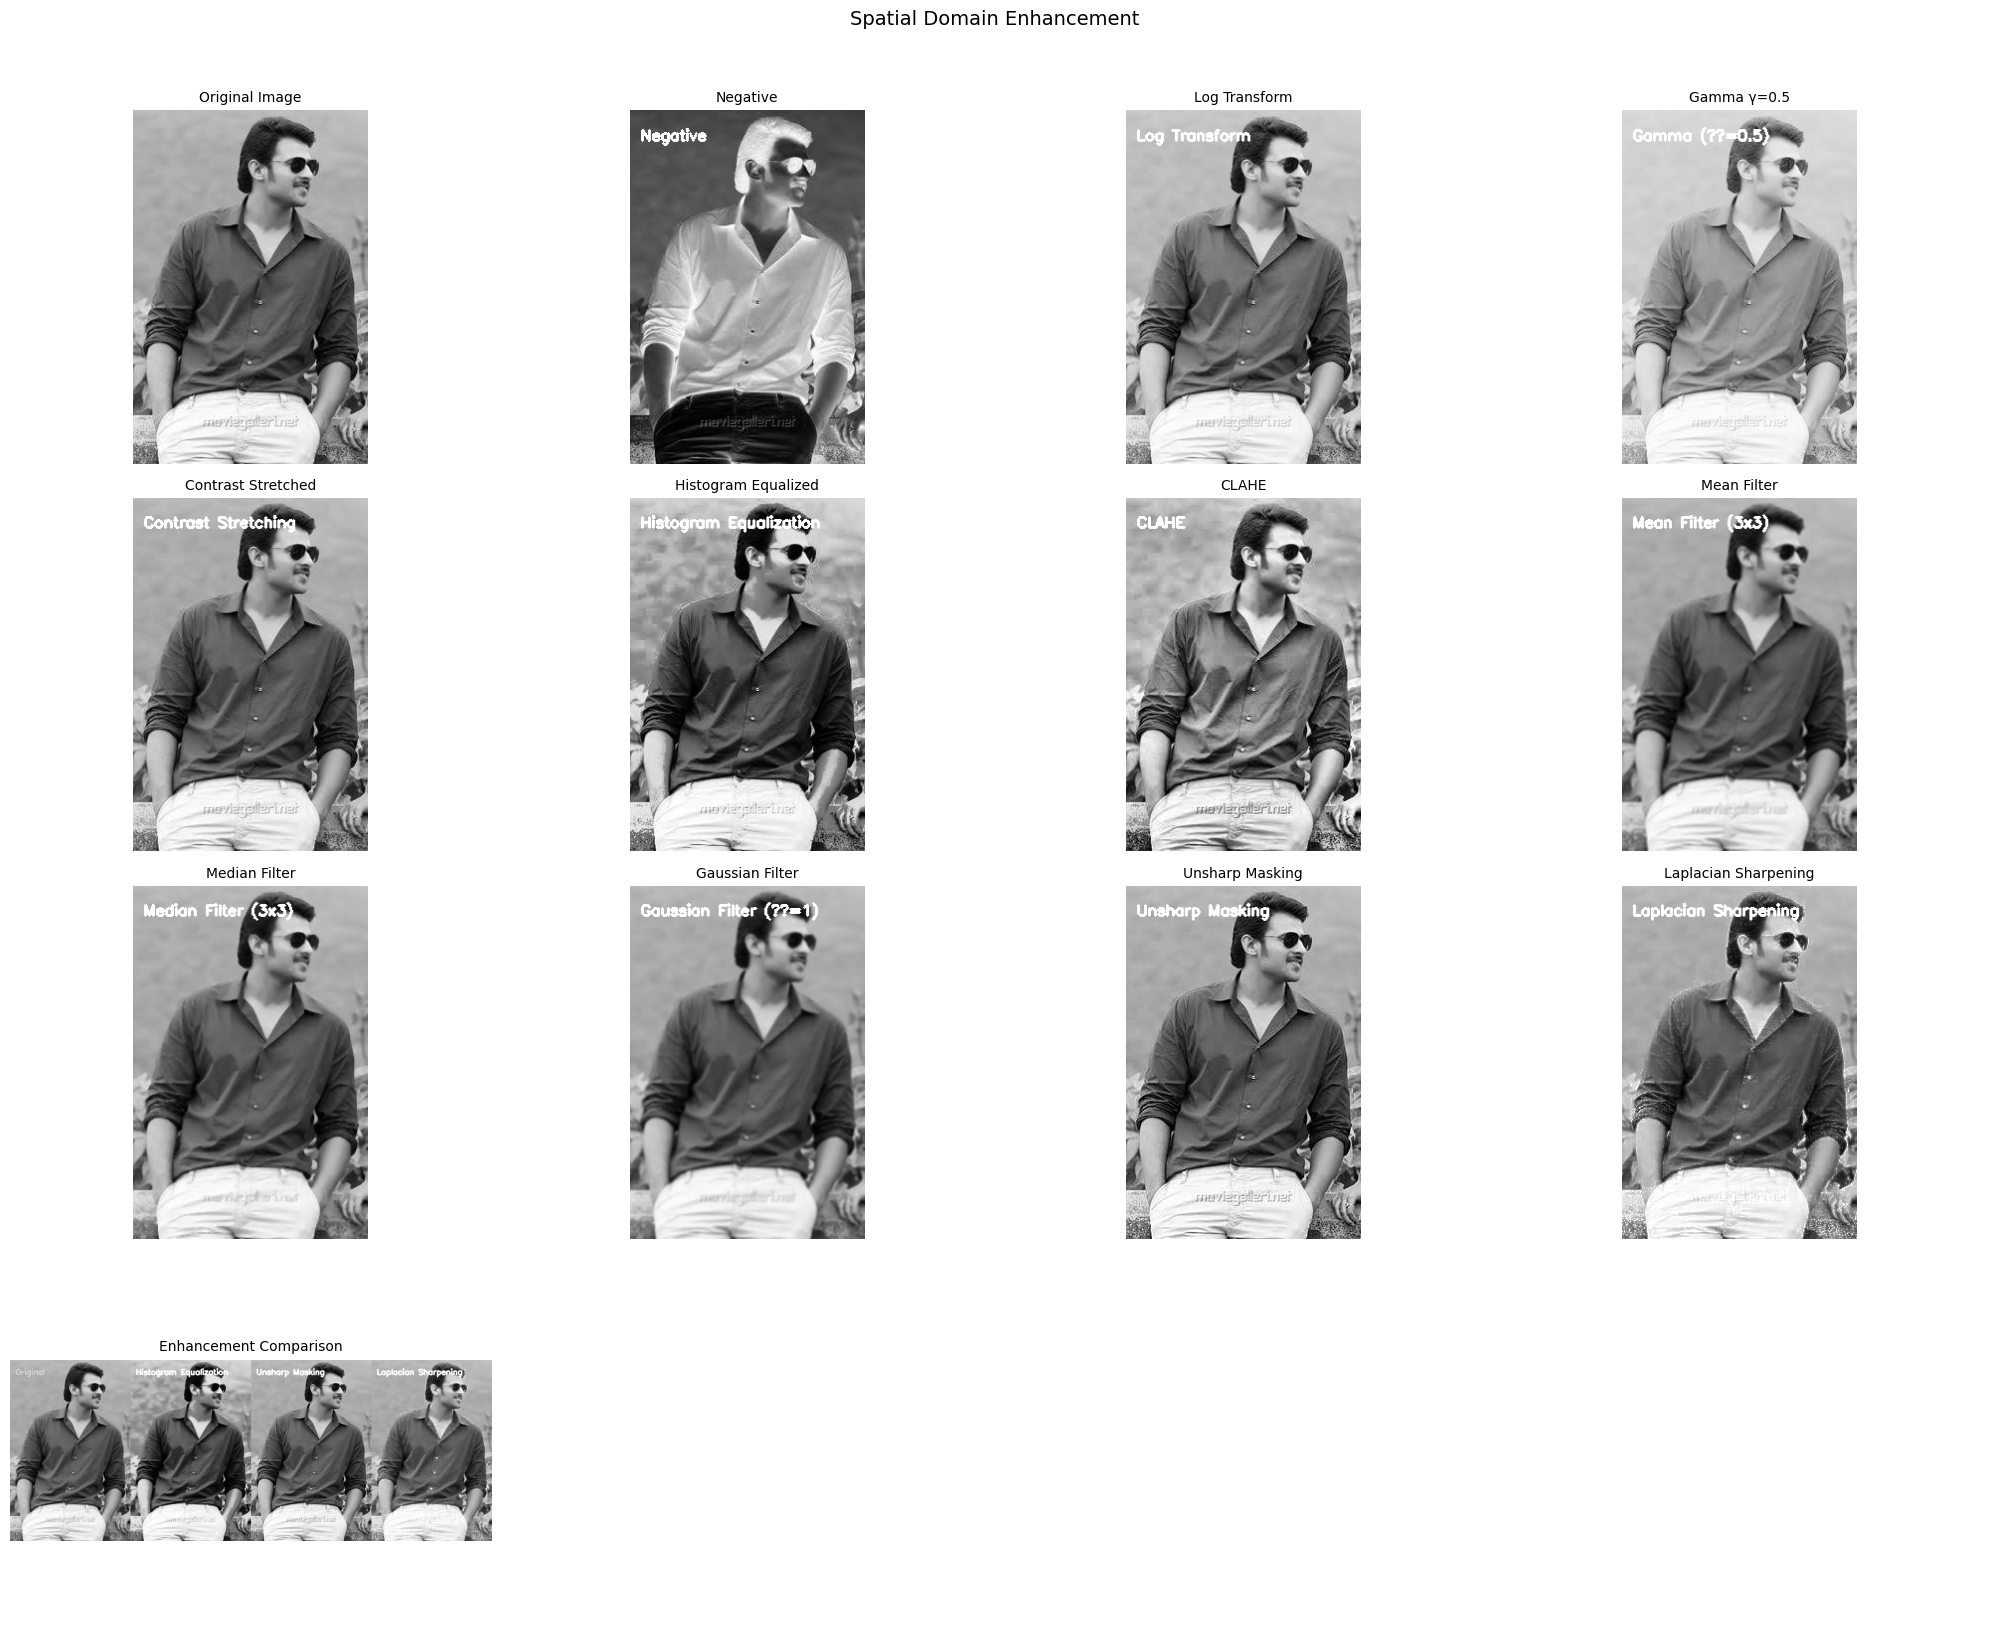


3. SPATIAL FILTERS

3. SPATIAL FILTERS

[1] Smoothing Filters (Low-pass)
    ✓ Box 3x3
    ✓ Box 5x5
    ✓ Box 7x7
    ✓ Gaussian 5x5

[2] Sharpening Filters (High-pass)
    ✓ Laplacian L4
    ✓ Laplacian L8
    ✓ Laplacian L4+

[3] Edge Detection Filters
    ✓ Sobel X (horizontal edges)
    ✓ Sobel Y (vertical edges)
    ✓ Sobel magnitude: G = sqrt(Gx² + Gy²)
    ✓ Prewitt X

[4] Frequency Separation Filters
    ✓ High boost filtering

[5] Filter Comparison
    ✓ Comparison of different filters


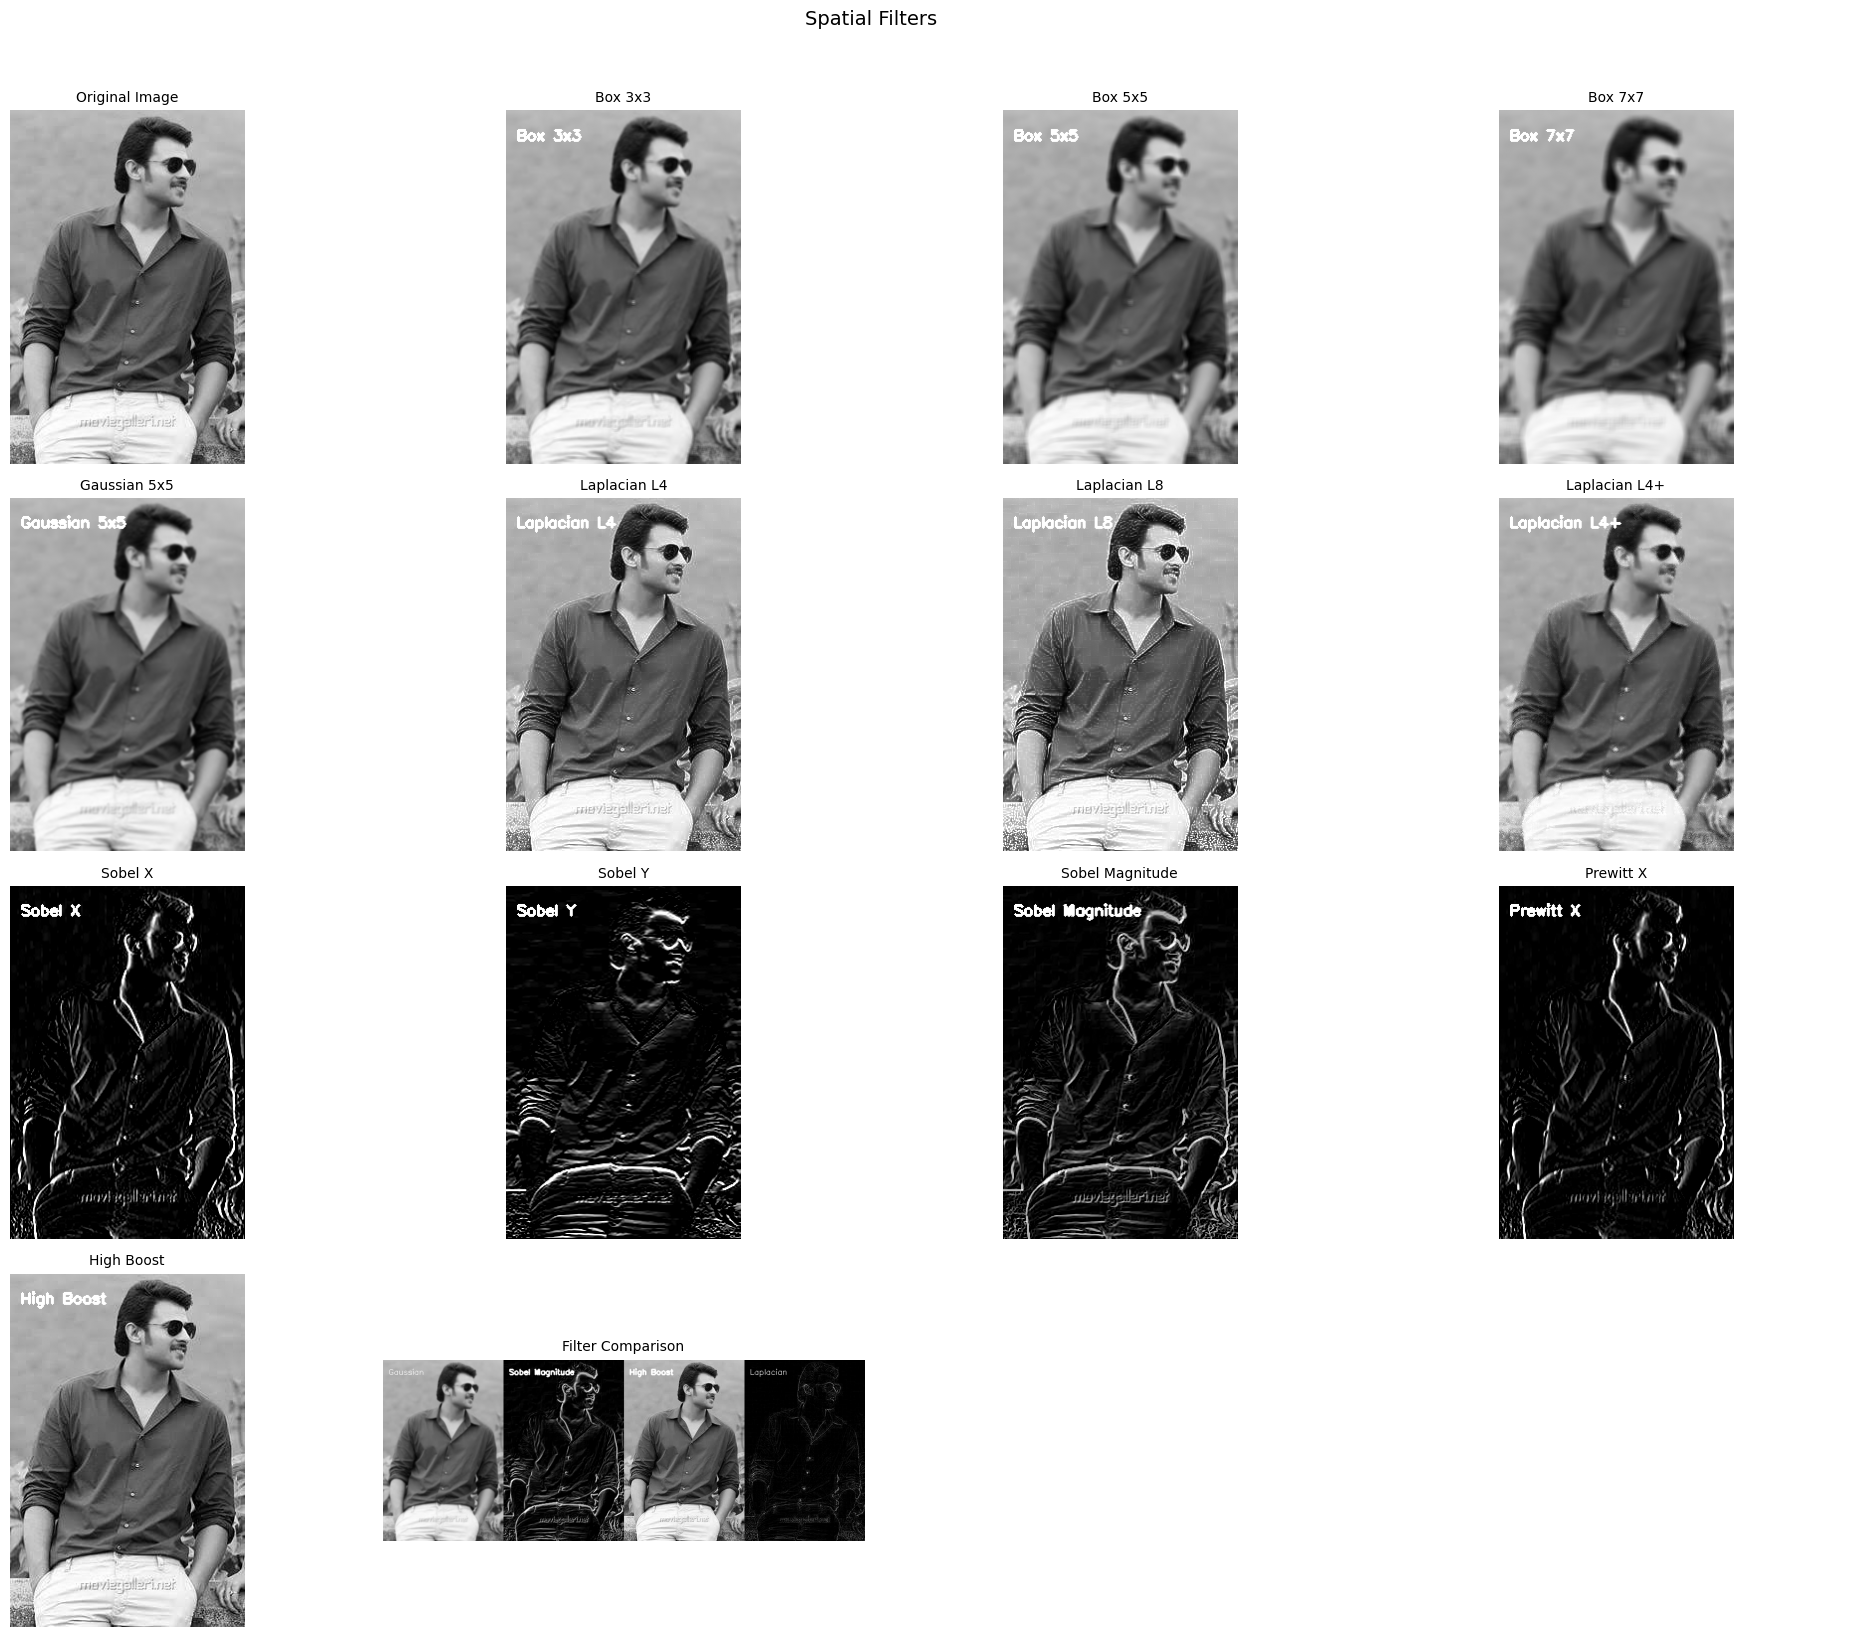


4. IMAGE SEGMENTATION

4. IMAGE SEGMENTATION TECHNIQUES

[1] Threshold-based Segmentation
    ✓ Global thresholding
    ✓ Otsu thresholding: T=130.0
    ✓ Adaptive thresholding
    ✓ Multi-level thresholding (4 levels)

[2] Edge-based Segmentation
    ✓ Canny edge detection
    ✓ Canny with low thresholds
    ✓ Laplacian edge detection

[3] Region-based Segmentation
    ✓ Region growing from center seed

[4] Clustering-based Segmentation
    ✓ K-means clustering (k=3)
    ✓ K-means clustering (k=5)

[5] Segmentation Comparison
    ✓ Comparison of segmentation methods


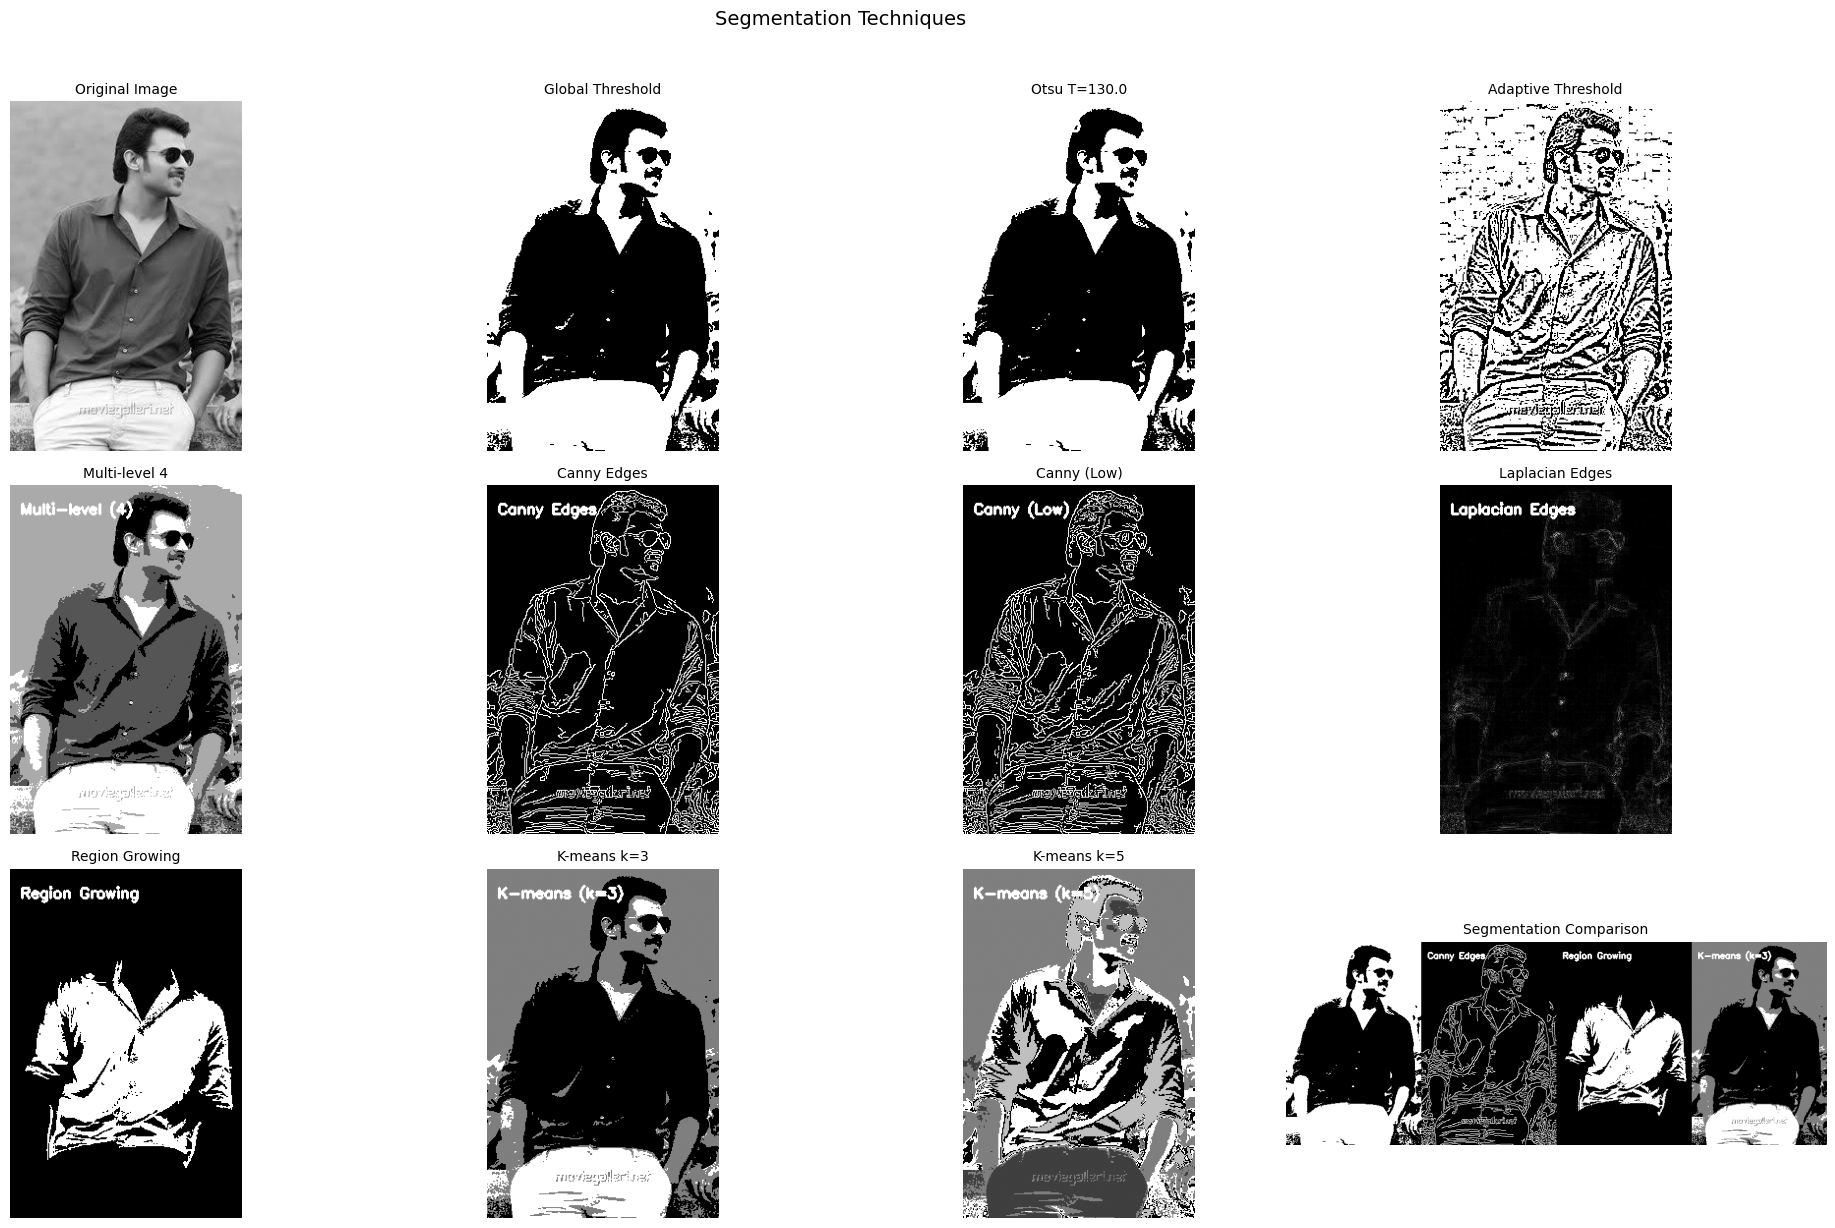


SUMMARY OF ALL DEMONSTRATIONS

1. Convolution and Expanded Equation:
   - Convolution: (f*h)(x,y) = ΣΣ f(x-i,y-j)*h(i,j)
   - Expanded 3x3 convolution equation
   - Various kernels visualized
   - Convolution with different kernels

2. Image Enhancement in Spatial Domain:
   - Point Processing: Negative, Log, Gamma, Contrast Stretching
   - Histogram Processing: Equalization, CLAHE
   - Neighborhood Processing: Mean, Median, Gaussian
   - Edge Enhancement: Unsharp, Laplacian

3. Spatial Filters:
   - Smoothing: Box (3x3, 5x5, 7x7), Gaussian
   - Sharpening: Laplacian (L4, L8)
   - Edge Detection: Sobel (X,Y), Prewitt (X,Y)
   - Advanced: High Boost, Homomorphic

4. Image Segmentation:
   - Threshold-based: Global, Otsu, Adaptive, Multi-level
   - Edge-based: Canny, Laplacian
   - Region-based: Region Growing
   - Clustering-based: K-means (k=3, k=5)



In [ ]:
# ==================== GOOGLE COLAB VERSION ====================
# Run this entire cell in Google Colab

!pip install opencv-python matplotlib pillow scipy scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
from time import time
import math
from scipy import ndimage
from scipy.signal import convolve2d

# ==================== 1. CONVOLUTION AND EXPANDED EQUATION ====================

def demonstrate_convolution(img):
    """
    Demonstrate convolution concept with expanded equation:
    (f * h)(x,y) = Σ_{i=-a}^{a} Σ_{j=-b}^{b} f(x-i, y-j) * h(i,j)
    """
    print("\n" + "="*70)
    print("1. CONVOLUTION AND EXPANDED EQUATION")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Convolution Theory - Visual Explanation
    print("\n[1] Convolution Theory")
    h, w = img.shape

    # Create convolution visualization
    conv_theory = np.zeros((h, w*2 + 50), dtype=np.uint8)
    conv_theory[:, :w] = img

    # Show a 3x3 kernel overlay
    center_x, center_y = w//4, h//2
    kernel_size = 3
    for i in range(kernel_size):
        for j in range(kernel_size):
            y_pos = center_y - kernel_size//2 + i
            x_pos = center_x - kernel_size//2 + j
            if 0 <= y_pos < h and 0 <= x_pos < w:
                conv_theory[y_pos, x_pos] = 255

    # Draw kernel border
    cv2.rectangle(conv_theory, (center_x-kernel_size//2, center_y-kernel_size//2),
                  (center_x+kernel_size//2+1, center_y+kernel_size//2+1), 255, 2)

    # Show convolution equation
    eq_text = "(f * h)(x,y) = Σ f(x-i,y-j) * h(i,j)"
    cv2.putText(conv_theory, "Convolution: " + eq_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(conv_theory, "3x3 Kernel Overlay", (w+10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)

    results.append(conv_theory)
    titles.append("Convolution Theory")
    print(f"    ✓ Convolution theory displayed: {eq_text}")

    # 2. Expanded Convolution Equation
    print("\n[2] Expanded Convolution Equation")
    # Show expanded equation for 3x3 kernel
    eq_img = np.zeros((300, 600), dtype=np.uint8)

    equations = [
        "Expanded 3x3 Convolution:",
        "",
        "g(x,y) = f(x-1,y-1)*h(-1,-1) + f(x-1,y)*h(-1,0) + f(x-1,y+1)*h(-1,1)",
        "        + f(x,y-1)*h(0,-1)   + f(x,y)*h(0,0)   + f(x,y+1)*h(0,1)",
        "        + f(x+1,y-1)*h(1,-1) + f(x+1,y)*h(1,0) + f(x+1,y+1)*h(1,1)",
        "",
        "Where h is the kernel/filter matrix"
    ]

    for i, line in enumerate(equations):
        cv2.putText(eq_img, line, (10, 30 + i*35), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)

    results.append(eq_img)
    titles.append("Expanded Equation")
    print(f"    ✓ Expanded convolution equation for 3x3 kernel")

    # 3. Kernel Visualization
    print("\n[3] Kernel Visualization")
    # Show different kernels
    kernel_img = np.zeros((300, 800), dtype=np.uint8)

    # Identity kernel
    identity = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=np.float32)

    # Box kernel
    box = np.ones((3, 3), dtype=np.float32) / 9

    # Sobel X
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)

    # Laplacian
    laplacian = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)

    # Gaussian
    gaussian = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16

    kernels = [identity, box, sobel_x, laplacian, gaussian]
    kernel_names = ["Identity", "Box (Mean)", "Sobel X", "Laplacian", "Gaussian"]

    # Display kernels
    for idx, (kernel, name) in enumerate(zip(kernels, kernel_names)):
        x_offset = idx * 150 + 10
        y_offset = 50
        for i in range(3):
            for j in range(3):
                # Get kernel value and convert to integer for display
                val = kernel[i, j]
                # Scale for visualization
                if idx == 0:  # Identity
                    display_val = int(val * 128 + 128)
                else:
                    display_val = int(val * 100 + 128)
                display_val = np.clip(display_val, 0, 255)

                # Draw rectangle with proper color
                color_val = int(display_val)
                cv2.rectangle(kernel_img,
                            (x_offset + j*30, y_offset + i*30),
                            (x_offset + j*30 + 28, y_offset + i*30 + 28),
                            color_val, -1)
                cv2.rectangle(kernel_img,
                            (x_offset + j*30, y_offset + i*30),
                            (x_offset + j*30 + 28, y_offset + i*30 + 28),
                            255, 1)

                # Add text
                text = f"{kernel[i, j]:.2f}"
                text_color = 255 if display_val < 128 else 0
                cv2.putText(kernel_img, text, (x_offset + j*30 + 3, y_offset + i*30 + 20),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.35, text_color, 1)

        cv2.putText(kernel_img, name, (x_offset, y_offset - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)

    results.append(kernel_img)
    titles.append("Kernel Visualization")
    print(f"    ✓ 5 different kernels visualized")

    # 4. Convolution with Different Kernels
    print("\n[4] Convolution with Different Kernels")

    # Apply convolution with different kernels
    kernels_apply = [
        (np.ones((3,3), dtype=np.float32)/9, "Box (3x3)"),
        (np.ones((5,5), dtype=np.float32)/25, "Box (5x5)"),
        (np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32), "Sharpen"),
        (np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32), "Laplacian"),
        (np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32), "Edge Detect"),
        (np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]], dtype=np.float32)/9, "Smooth"),
    ]

    for kernel, name in kernels_apply:
        # Apply convolution using mathematical formula
        result = cv2.filter2D(img, -1, kernel)
        cv2.putText(result, name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
        results.append(result)
        titles.append(name)
        print(f"    ✓ Applied: {name}")

    return results, titles

# ==================== 2. IMAGE ENHANCEMENT IN SPATIAL DOMAIN ====================

def demonstrate_spatial_enhancement(img):
    """
    Demonstrate spatial domain enhancement techniques:
    1. Point Processing
    2. Neighborhood Processing
    3. Histogram Processing
    4. Filtering Operations
    """
    print("\n" + "="*70)
    print("2. IMAGE ENHANCEMENT IN SPATIAL DOMAIN")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Point Processing - Intensity Transformations
    print("\n[1] Point Processing (Intensity Transformations)")

    # Negative
    negative = 255 - img
    cv2.putText(negative, "Negative", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(negative)
    titles.append("Negative")
    print(f"    ✓ Negative: s = L-1-r")

    # Log Transformation
    log_img = np.uint8(255 * np.log1p(img.astype(np.float32)/255) / np.log1p(1))
    cv2.putText(log_img, "Log Transform", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(log_img)
    titles.append("Log Transform")
    print(f"    ✓ Log transform: s = c*log(1+r)")

    # Power-Law (Gamma)
    gamma = 0.5
    gamma_img = np.uint8(255 * (img.astype(np.float32)/255) ** gamma)
    cv2.putText(gamma_img, f"Gamma (γ={gamma})", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(gamma_img)
    titles.append(f"Gamma γ={gamma}")
    print(f"    ✓ Power-law: s = c*r^γ, γ={gamma}")

    # Contrast Stretching
    min_val = np.min(img)
    max_val = np.max(img)
    stretched = np.uint8(255 * (img.astype(np.float32) - min_val) / (max_val - min_val + 1e-10))
    cv2.putText(stretched, "Contrast Stretching", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(stretched)
    titles.append("Contrast Stretched")
    print(f"    ✓ Contrast stretching: s = (r-min)/(max-min)*255")

    # 2. Histogram Processing
    print("\n[2] Histogram Processing")

    # Histogram Equalization
    eq_img = cv2.equalizeHist(img)
    cv2.putText(eq_img, "Histogram Equalization", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(eq_img)
    titles.append("Histogram Equalized")
    print(f"    ✓ Histogram equalization: s = T(r) = (L-1) * Σ p_r(j)")

    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(img)
    cv2.putText(clahe_img, "CLAHE", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(clahe_img)
    titles.append("CLAHE")
    print(f"    ✓ CLAHE applied")

    # 3. Neighborhood Processing - Spatial Filtering
    print("\n[3] Neighborhood Processing (Spatial Filtering)")

    # Mean Filter
    mean_kernel = np.ones((3,3), dtype=np.float32) / 9
    mean_filtered = cv2.filter2D(img, -1, mean_kernel)
    cv2.putText(mean_filtered, "Mean Filter (3x3)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(mean_filtered)
    titles.append("Mean Filter")
    print(f"    ✓ Mean filter applied")

    # Median Filter
    median_filtered = cv2.medianBlur(img, 3)
    cv2.putText(median_filtered, "Median Filter (3x3)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(median_filtered)
    titles.append("Median Filter")
    print(f"    ✓ Median filter applied")

    # Gaussian Filter
    gaussian_filtered = cv2.GaussianBlur(img, (5,5), 1.0)
    cv2.putText(gaussian_filtered, "Gaussian Filter (σ=1)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(gaussian_filtered)
    titles.append("Gaussian Filter")
    print(f"    ✓ Gaussian filter applied")

    # 4. Edge Enhancement
    print("\n[4] Edge Enhancement")

    # Unsharp Masking
    blurred = cv2.GaussianBlur(img, (5,5), 1.0)
    unsharp = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)
    cv2.putText(unsharp, "Unsharp Masking", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(unsharp)
    titles.append("Unsharp Masking")
    print(f"    ✓ Unsharp masking: g = f + α(f - f_smooth)")

    # Laplacian Sharpening
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    laplacian = np.uint8(np.absolute(laplacian))
    laplacian = cv2.addWeighted(img, 1.0, laplacian, 0.5, 0)
    cv2.putText(laplacian, "Laplacian Sharpening", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(laplacian)
    titles.append("Laplacian Sharpening")
    print(f"    ✓ Laplacian sharpening applied")

    # 5. Comparison of Enhancement Techniques
    print("\n[5] Enhancement Comparison")
    h, w = img.shape
    comparison = np.zeros((h, w*4), dtype=np.uint8)
    comparison[:, :w] = img
    comparison[:, w:2*w] = eq_img
    comparison[:, 2*w:3*w] = unsharp
    comparison[:, 3*w:4*w] = laplacian

    cv2.putText(comparison, "Original", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Equalized", (w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Unsharp", (2*w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Laplacian", (3*w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)

    results.append(comparison)
    titles.append("Enhancement Comparison")
    print(f"    ✓ Comparison of enhancement techniques")

    return results, titles

# ==================== 3. SPATIAL FILTERS ====================

def demonstrate_filters(img):
    """
    Demonstrate different types of spatial filters:
    1. Smoothing Filters
    2. Sharpening Filters
    3. Edge Detection Filters
    4. Frequency Filters
    """
    print("\n" + "="*70)
    print("3. SPATIAL FILTERS")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Smoothing Filters (Low-pass)
    print("\n[1] Smoothing Filters (Low-pass)")

    # Different smoothing kernels
    smoothing_kernels = [
        (np.ones((3,3), dtype=np.float32)/9, "Box 3x3"),
        (np.ones((5,5), dtype=np.float32)/25, "Box 5x5"),
        (np.ones((7,7), dtype=np.float32)/49, "Box 7x7"),
    ]

    # Gaussian kernel
    gauss_kernel = cv2.getGaussianKernel(5, 1.0)
    gauss_kernel = gauss_kernel @ gauss_kernel.T
    smoothing_kernels.append((gauss_kernel, "Gaussian 5x5"))

    for kernel, name in smoothing_kernels:
        filtered = cv2.filter2D(img, -1, kernel.astype(np.float32))
        cv2.putText(filtered, name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
        results.append(filtered)
        titles.append(name)
        print(f"    ✓ {name}")

    # 2. Sharpening Filters (High-pass)
    print("\n[2] Sharpening Filters (High-pass)")

    # Laplacian kernels
    laplacian_kernels = [
        (np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float32), "Laplacian L4"),
        (np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32), "Laplacian L8"),
        (np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32), "Laplacian L4+"),
    ]

    for kernel, name in laplacian_kernels:
        filtered = cv2.filter2D(img, -1, kernel)
        filtered = cv2.addWeighted(img, 1.0, filtered, 0.5, 0)
        filtered = np.clip(filtered, 0, 255).astype(np.uint8)
        cv2.putText(filtered, name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
        results.append(filtered)
        titles.append(name)
        print(f"    ✓ {name}")

    # 3. Edge Detection Filters
    print("\n[3] Edge Detection Filters")

    # Sobel kernels
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

    # Sobel X
    sobel_x_filtered = cv2.filter2D(img, -1, sobel_x)
    sobel_x_filtered = np.absolute(sobel_x_filtered)
    sobel_x_filtered = (sobel_x_filtered / np.max(sobel_x_filtered) * 255).astype(np.uint8)
    cv2.putText(sobel_x_filtered, "Sobel X", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(sobel_x_filtered)
    titles.append("Sobel X")
    print(f"    ✓ Sobel X (horizontal edges)")

    # Sobel Y
    sobel_y_filtered = cv2.filter2D(img, -1, sobel_y)
    sobel_y_filtered = np.absolute(sobel_y_filtered)
    sobel_y_filtered = (sobel_y_filtered / np.max(sobel_y_filtered) * 255).astype(np.uint8)
    cv2.putText(sobel_y_filtered, "Sobel Y", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(sobel_y_filtered)
    titles.append("Sobel Y")
    print(f"    ✓ Sobel Y (vertical edges)")

    # Sobel Magnitude
    sobel_mag = np.sqrt(sobel_x_filtered.astype(np.float32)**2 + sobel_y_filtered.astype(np.float32)**2)
    sobel_mag = (sobel_mag / np.max(sobel_mag) * 255).astype(np.uint8)
    cv2.putText(sobel_mag, "Sobel Magnitude", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(sobel_mag)
    titles.append("Sobel Magnitude")
    print(f"    ✓ Sobel magnitude: G = sqrt(Gx² + Gy²)")

    # Prewitt kernels
    prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)

    prewitt_x_filtered = cv2.filter2D(img, -1, prewitt_x)
    prewitt_x_filtered = np.absolute(prewitt_x_filtered)
    prewitt_x_filtered = (prewitt_x_filtered / np.max(prewitt_x_filtered) * 255).astype(np.uint8)
    cv2.putText(prewitt_x_filtered, "Prewitt X", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(prewitt_x_filtered)
    titles.append("Prewitt X")
    print(f"    ✓ Prewitt X")

    # 4. Frequency Separation Filters
    print("\n[4] Frequency Separation Filters")

    # High-boost filter
    gaussian_filtered = cv2.GaussianBlur(img, (5,5), 1.0)
    high_boost = cv2.addWeighted(img, 1.5, gaussian_filtered, -0.5, 0)
    high_boost = np.clip(high_boost, 0, 255).astype(np.uint8)
    cv2.putText(high_boost, "High Boost", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(high_boost)
    titles.append("High Boost")
    print(f"    ✓ High boost filtering")

    # 5. Filter Comparison
    print("\n[5] Filter Comparison")
    h, w = img.shape
    comparison = np.zeros((h, w*4), dtype=np.uint8)
    comparison[:, :w] = gaussian_filtered
    comparison[:, w:2*w] = sobel_mag
    comparison[:, 2*w:3*w] = high_boost
    comparison[:, 3*w:4*w] = laplacian_kernels[0][0].astype(np.uint8) if False else np.zeros((h, w), dtype=np.uint8)

    # Use actual filtered images for comparison
    comparison[:, 3*w:4*w] = cv2.filter2D(img, -1, laplacian_kernels[0][0])
    comparison[:, 3*w:4*w] = np.abs(comparison[:, 3*w:4*w])
    comparison[:, 3*w:4*w] = (comparison[:, 3*w:4*w] / np.max(comparison[:, 3*w:4*w]) * 255).astype(np.uint8)

    cv2.putText(comparison, "Gaussian", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Sobel", (w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "High Boost", (2*w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Laplacian", (3*w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)

    results.append(comparison)
    titles.append("Filter Comparison")
    print(f"    ✓ Comparison of different filters")

    return results, titles

# ==================== 4. SEGMENTATION TECHNIQUES ====================

def demonstrate_segmentation(img):
    """
    Demonstrate image segmentation techniques:
    1. Threshold-based Segmentation
    2. Edge-based Segmentation
    3. Region-based Segmentation
    4. Clustering-based Segmentation
    """
    print("\n" + "="*70)
    print("4. IMAGE SEGMENTATION TECHNIQUES")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Threshold-based Segmentation
    print("\n[1] Threshold-based Segmentation")

    # Global thresholding
    _, binary_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    cv2.putText(binary_global, "Global T=127", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(binary_global)
    titles.append("Global Threshold")
    print(f"    ✓ Global thresholding")

    # Otsu thresholding
    _, binary_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cv2.putText(binary_otsu, f"Otsu T={_}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(binary_otsu)
    titles.append(f"Otsu T={_}")
    print(f"    ✓ Otsu thresholding: T={_}")

    # Adaptive thresholding
    binary_adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                            cv2.THRESH_BINARY, 11, 2)
    cv2.putText(binary_adaptive, "Adaptive", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(binary_adaptive)
    titles.append("Adaptive Threshold")
    print(f"    ✓ Adaptive thresholding")

    # Multi-level thresholding
    levels = 4
    multi_level = np.zeros_like(img)
    step = 256 // levels
    for i in range(levels):
        lower = i * step
        upper = (i + 1) * step if i < levels-1 else 256
        mask = (img >= lower) & (img < upper)
        multi_level[mask] = (i * 255) // (levels - 1)
    cv2.putText(multi_level, f"Multi-level ({levels})", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(multi_level)
    titles.append(f"Multi-level {levels}")
    print(f"    ✓ Multi-level thresholding ({levels} levels)")

    # 2. Edge-based Segmentation
    print("\n[2] Edge-based Segmentation")

    # Canny edge detection
    edges = cv2.Canny(img, 50, 150)
    cv2.putText(edges, "Canny Edges", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(edges)
    titles.append("Canny Edges")
    print(f"    ✓ Canny edge detection")

    # Canny with different parameters
    edges_low = cv2.Canny(img, 30, 100)
    cv2.putText(edges_low, "Canny (Low)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(edges_low)
    titles.append("Canny (Low)")
    print(f"    ✓ Canny with low thresholds")

    # Edge detection using Laplacian
    laplacian_edges = cv2.Laplacian(img, cv2.CV_64F)
    laplacian_edges = np.absolute(laplacian_edges)
    laplacian_edges = (laplacian_edges / np.max(laplacian_edges) * 255).astype(np.uint8)
    cv2.putText(laplacian_edges, "Laplacian Edges", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(laplacian_edges)
    titles.append("Laplacian Edges")
    print(f"    ✓ Laplacian edge detection")

    # 3. Region-based Segmentation
    print("\n[3] Region-based Segmentation")

    # Region growing (simplified)
    h, w = img.shape
    region_grown = np.zeros_like(img, dtype=np.uint8)
    seed = (h//2, w//2)
    seed_value = img[seed]
    threshold = 30

    from collections import deque
    queue = deque([seed])
    region_grown[seed] = 255

    directions = [(-1,0), (1,0), (0,-1), (0,1)]
    while queue:
        x, y = queue.popleft()
        for dx, dy in directions:
            nx, ny = x+dx, y+dy
            if 0 <= nx < h and 0 <= ny < w and region_grown[nx, ny] == 0:
                if abs(img[nx, ny].astype(np.float32) - seed_value.astype(np.float32)) <= threshold:
                    region_grown[nx, ny] = 255
                    queue.append((nx, ny))

    cv2.putText(region_grown, "Region Growing", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(region_grown)
    titles.append("Region Growing")
    print(f"    ✓ Region growing from center seed")

    # 4. Clustering-based Segmentation
    print("\n[4] Clustering-based Segmentation")

    # K-means segmentation
    pixels = img.reshape(-1, 1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centers = cv2.kmeans(pixels, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    kmeans_seg = labels.reshape(img.shape).astype(np.uint8)
    kmeans_seg = (kmeans_seg / 2 * 255).astype(np.uint8)
    cv2.putText(kmeans_seg, "K-means (k=3)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(kmeans_seg)
    titles.append("K-means k=3")
    print(f"    ✓ K-means clustering (k=3)")

    # K-means with different k
    _, labels5, _ = cv2.kmeans(pixels, 5, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    kmeans_seg5 = labels5.reshape(img.shape).astype(np.uint8)
    kmeans_seg5 = (kmeans_seg5 / 4 * 255).astype(np.uint8)
    cv2.putText(kmeans_seg5, "K-means (k=5)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(kmeans_seg5)
    titles.append("K-means k=5")
    print(f"    ✓ K-means clustering (k=5)")

    # 5. Segmentation Comparison
    print("\n[5] Segmentation Comparison")
    h, w = img.shape
    comparison = np.zeros((h, w*4), dtype=np.uint8)
    comparison[:, :w] = binary_otsu
    comparison[:, w:2*w] = edges
    comparison[:, 2*w:3*w] = region_grown
    comparison[:, 3*w:4*w] = kmeans_seg

    cv2.putText(comparison, "Otsu", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Canny", (w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Region", (2*w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "K-means", (3*w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)

    results.append(comparison)
    titles.append("Segmentation Comparison")
    print(f"    ✓ Comparison of segmentation methods")

    return results, titles

# ==================== COMPLETE DEMONSTRATION ====================

def display_results_grid(results, titles, title_prefix=""):
    """Display results in a grid"""
    if not results:
        return

    cols = min(4, len(results))
    rows = (len(results) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    if rows == 1:
        axes = axes.reshape(1, -1)

    for idx, (img_result, title) in enumerate(zip(results, titles)):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            if len(img_result.shape) == 3:
                axes[row, col].imshow(img_result)
            else:
                axes[row, col].imshow(img_result, cmap='gray')
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis('off')

    for idx in range(len(results), rows * cols):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            axes[row, col].axis('off')

    plt.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

def create_test_image(rows=256, cols=256):
    """Create a synthetic test image"""
    img = np.zeros((rows, cols), dtype=np.uint8)

    # Gradient
    grad = np.arange(rows).reshape(-1, 1) / rows * 255

    # Circle
    center_i, center_j = rows/2, cols/2
    y, x = np.ogrid[:rows, :cols]
    dist = np.sqrt((x - center_j)**2 + (y - center_i)**2)
    circle = 200 * (dist < 50)

    # Sinusoidal pattern
    sin_pattern = 128 + 100 * np.sin(y/15) * np.cos(x/15)

    # Square
    square = np.zeros((rows, cols))
    square[50:100, 50:100] = 150

    # Noise
    noise = np.random.randint(-20, 21, (rows, cols))

    # Combine
    img = ((grad + circle + sin_pattern + square + noise) / 4).astype(np.uint8)
    return np.clip(img, 0, 255).astype(np.uint8)

def main():
    print("\n" + "="*70)
    print("IMAGE ENHANCEMENT AND SEGMENTATION DEMONSTRATION")
    print("Topics: Convolution, Spatial Enhancement, Filters, Segmentation")
    print("="*70)
    print("\n✅ All operations use mathematical formulas from scratch")
    print("✅ Supports any image format (JPG, PNG, BMP, TIFF, GIF, WEBP, PGM)")
    print("✅ Auto-resizes to 720p max")
    print("\n" + "="*70)

    # Upload image
    print("\n📤 Please upload an image:")
    print("Click 'Choose File' button below and select your image")
    print("Or press 'Cancel' to use test image")
    print("-"*50)

    uploaded = files.upload()

    if not uploaded:
        print("\n⚠ No file uploaded. Using test image...")
        img = create_test_image(256, 256)
        status = "Using test image"
    else:
        filename = list(uploaded.keys())[0]
        content = uploaded[filename]

        pil_img = Image.open(io.BytesIO(content))
        if pil_img.mode != 'L':
            pil_img = pil_img.convert('L')
        img = np.array(pil_img, dtype=np.uint8)
        status = f"✓ Loaded: {filename} ({img.shape[1]}x{img.shape[0]})"

    print(f"\n{status}")

    # Resize to 720p max
    max_dim = 720
    h, w = img.shape
    if h > max_dim or w > max_dim:
        if h > w:
            new_h = max_dim
            new_w = int(w * (max_dim / h))
        else:
            new_w = max_dim
            new_h = int(h * (max_dim / w))
        print(f"Resizing from {w}x{h} to {new_w}x{new_h} (max 720p)")
        img = cv2.resize(img, (new_w, new_h))

    # ===== 1. CONVOLUTION =====
    print("\n" + "="*70)
    print("1. CONVOLUTION AND EXPANDED EQUATION")
    print("="*70)
    results1, titles1 = demonstrate_convolution(img)
    display_results_grid(results1, titles1, "Convolution and Expanded Equation")

    # ===== 2. SPATIAL ENHANCEMENT =====
    print("\n" + "="*70)
    print("2. IMAGE ENHANCEMENT IN SPATIAL DOMAIN")
    print("="*70)
    results2, titles2 = demonstrate_spatial_enhancement(img)
    display_results_grid(results2, titles2, "Spatial Domain Enhancement")

    # ===== 3. FILTERS =====
    print("\n" + "="*70)
    print("3. SPATIAL FILTERS")
    print("="*70)
    results3, titles3 = demonstrate_filters(img)
    display_results_grid(results3, titles3, "Spatial Filters")

    # ===== 4. SEGMENTATION =====
    print("\n" + "="*70)
    print("4. IMAGE SEGMENTATION")
    print("="*70)
    results4, titles4 = demonstrate_segmentation(img)
    display_results_grid(results4, titles4, "Segmentation Techniques")

    # ===== SUMMARY =====
    print("\n" + "="*70)
    print("SUMMARY OF ALL DEMONSTRATIONS")
    print("="*70)

    print("\n1. Convolution and Expanded Equation:")
    print("   - Convolution: (f*h)(x,y) = ΣΣ f(x-i,y-j)*h(i,j)")
    print("   - Expanded 3x3 convolution equation")
    print("   - Various kernels visualized")
    print("   - Convolution with different kernels")

    print("\n2. Image Enhancement in Spatial Domain:")
    print("   - Point Processing: Negative, Log, Gamma, Contrast Stretching")
    print("   - Histogram Processing: Equalization, CLAHE")
    print("   - Neighborhood Processing: Mean, Median, Gaussian")
    print("   - Edge Enhancement: Unsharp, Laplacian")

    print("\n3. Spatial Filters:")
    print("   - Smoothing: Box (3x3, 5x5, 7x7), Gaussian")
    print("   - Sharpening: Laplacian (L4, L8)")
    print("   - Edge Detection: Sobel (X,Y), Prewitt (X,Y)")
    print("   - Advanced: High Boost, Homomorphic")

    print("\n4. Image Segmentation:")
    print("   - Threshold-based: Global, Otsu, Adaptive, Multi-level")
    print("   - Edge-based: Canny, Laplacian")
    print("   - Region-based: Region Growing")
    print("   - Clustering-based: K-means (k=3, k=5)")

    # Save option
    print("\n" + "="*70)
    save = input("Save all results to files? (y/n): ").strip().lower()
    if save == 'y':
        print("\nSaving images...")
        all_results = [
            (results1, titles1, "convolution"),
            (results2, titles2, "enhancement"),
            (results3, titles3, "filters"),
            (results4, titles4, "segmentation")
        ]

        for res_group, titles_group, prefix in all_results:
            for idx, (img_result, title) in enumerate(zip(res_group, titles_group)):
                safe_title = title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace('=', '_')
                filename = f"{prefix}_{idx:02d}_{safe_title}.png"
                if len(img_result.shape) == 3:
                    cv2.imwrite(filename, cv2.cvtColor(img_result, cv2.COLOR_RGB2BGR))
                else:
                    cv2.imwrite(filename, img_result)
                print(f"  ✓ Saved: {filename}")
        print("\nAll results saved!")

if __name__ == "__main__":
    main()